# Study 09 — How much history should the estimate remember?

Study 08 showed that a rolling window can make an estimate respond more quickly when a player's underlying ability genuinely changes. But that responsiveness came at a cost: using fewer observations made the estimate more variable.

This study keeps exactly the same simplified snooker model and changes only the amount of recent history retained.

We will compare rolling windows of:

- 100 frames;
- 250 frames;
- 500 frames.

The simulated player will again have a true frame-win probability of 58% for the first 1,000 frames, followed by a genuine increase to 64%.

The question here is deliberately descriptive rather than an optimisation problem:

**How does the amount of history retained change the balance between responsiveness and stability?**

A shorter window should forget outdated observations more quickly and therefore respond faster to the change, but it should also fluctuate more because it is based on fewer frames.

A longer window should produce a more stable estimate, but it should take longer to forget observations generated under the player's old level of ability.

We are not yet trying to decide which window is best. We are isolating the trade-off created by window size.

## Model setup

We will use the same underlying process as Studies 07 and 08 so that window size is the only thing that changes.

The simulated career contains 2,000 independent frames:

- frames 1–1,000: true win probability = 58%;
- frames 1,001–2,000: true win probability = 64%.

There is no momentum or other dependence between frames. Each result is generated independently using the probability that applies at that point in the career.

For each simulated frame, we will calculate three rolling estimates:

- the proportion won in the most recent 100 frames;
- the proportion won in the most recent 250 frames;
- the proportion won in the most recent 500 frames.

A rolling estimate therefore answers: **what proportion of the last \(n\) frames did the player win?**

Before a full window exists, we will leave its estimate undefined rather than silently using a smaller sample. This keeps each series comparable: a 500-frame estimate always means an estimate based on exactly 500 frames.

In [1]:
# Keep the underlying ability path identical to Studies 07 and 08.
p_before = 0.58
p_after = 0.64

change_frame = 1_000
total_frames = 2_000

# Study 09 changes only how much recent history the estimator remembers.
window_sizes = [100, 250, 500]

p_before, p_after, change_frame, total_frames, window_sizes

(0.58, 0.64, 1000, 2000, [100, 250, 500])

In [2]:
import numpy as np

# Each frame gets the true win probability that applies at that point.
true_probability = np.full(total_frames, p_before)
true_probability[change_frame:] = p_after

true_probability[:5], true_probability[995:1005], true_probability[-5:]

(array([0.58, 0.58, 0.58, 0.58, 0.58]),
 array([0.58, 0.58, 0.58, 0.58, 0.58, 0.64, 0.64, 0.64, 0.64, 0.64]),
 array([0.64, 0.64, 0.64, 0.64, 0.64]))

## Simulate one career

Each frame result is a **Bernoulli trial**: there are only two possible outcomes.

- win = 1;
- loss = 0.

For each frame, we draw one random result using the true win probability assigned to that frame.

The underlying probability path is fixed, but the observed wins and losses will fluctuate randomly around it. That sampling noise is what makes rolling estimates move around even when true ability itself is unchanged.

In [3]:
# Use a fixed seed so this simulated career is reproducible.
rng = np.random.default_rng(42)

# A frame is recorded as 1 when the random draw falls below its true win probability.
frame_wins = (rng.random(total_frames) < true_probability).astype(int)

frame_wins[:20], frame_wins.sum()

(array([0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0]),
 np.int64(1211))

In [4]:
import pandas as pd

results = pd.Series(frame_wins)

rolling_estimates = {}

for window in window_sizes:
    # Require a complete window so every estimate uses exactly the stated number of frames.
    rolling_estimates[window] = results.rolling(
        window=window,
        min_periods=window
    ).mean()

# Check the first point at which each window becomes available.
[
    (window, rolling_estimates[window].first_valid_index())
    for window in window_sizes
]

[(100, 99), (250, 249), (500, 499)]

## First isolate responsiveness from random noise

A simulated rolling estimate mixes together two effects:

1. **responsiveness** — how quickly the window forgets observations generated under the old 58% ability level;
2. **sampling variability** — the random fluctuation caused by estimating a probability from a finite number of wins and losses.

It is useful to separate these before looking at the noisy simulated career.

We can first calculate the **expected rolling estimate**. Instead of rolling over actual wins and losses, we roll over the true frame-win probabilities themselves.

This tells us where each estimator would be centred on average.

After the change at frame 1,001, every new 64% observation entering a window replaces an older 58% observation. A shorter window will therefore purge the old 58% history sooner.

If the new ability level remains at 64%, we expect:

- the 100-frame window to contain only post-change frames after 100 new frames;
- the 250-frame window after 250 new frames;
- the 500-frame window after 500 new frames.

So window size directly determines how long stale history can remain in the estimate.

In [5]:
true_probability_series = pd.Series(true_probability)

expected_rolling = {}

for window in window_sizes:
    # Rolling over the probabilities themselves removes sampling noise.
    # The result is the expected value of each rolling estimator.
    expected_rolling[window] = true_probability_series.rolling(
        window=window,
        min_periods=window
    ).mean()

# Inspect several points after the change.
check_frames = [1_000, 1_050, 1_100, 1_250, 1_500]

[
    (
        frame,
        *[
            expected_rolling[window].iloc[frame - 1]
            for window in window_sizes
        ]
    )
    for frame in check_frames
]

[(1000, np.float64(0.58), np.float64(0.58), np.float64(0.58)),
 (1050,
  np.float64(0.6099999999999999),
  np.float64(0.592),
  np.float64(0.5859999999999999)),
 (1100, np.float64(0.64), np.float64(0.604), np.float64(0.5919999999999999)),
 (1250, np.float64(0.64), np.float64(0.64), np.float64(0.61)),
 (1500, np.float64(0.64), np.float64(0.64), np.float64(0.64))]

### Window size determines how quickly stale history disappears

The expected values make the responsiveness trade-off explicit.

At frame 1,050, only 50 post-change frames have occurred:

- 100-frame window: 61.0%;
- 250-frame window: 59.2%;
- 500-frame window: 58.6%.

All three estimates have begun moving toward the new 64% level, but the shortest window moves fastest because those 50 new frames replace a much larger proportion of its retained history.

By frame 1,100, the 100-frame window contains no pre-change observations and has reached an expected estimate of 64%.

The 250-frame window is still only at 60.4%, while the 500-frame window is at 59.2%.

At frame 1,250:

- the 100-frame window is already fully adapted;
- the 250-frame window has just fully adapted;
- the 500-frame window is still centred at only 61.0%.

The 500-frame window does not completely forget the old 58% observations until frame 1,500.

So, under this abrupt and permanent change, the time required for a fixed rolling estimator to become fully representative of the new level is determined directly by its window length.

Shorter windows remove stale history sooner. Longer windows preserve it for longer.

## Smaller windows should be noisier

Responsiveness is only half of the trade-off.

A rolling estimate is based on a finite sample of wins and losses, so it will vary randomly even when the player's true ability is fixed.

For an estimated win probability $\hat{p}$ based on $n$ independent frames, the standard deviation of the estimate is:

$$
\sqrt{\frac{p(1-p)}{n}}
$$

This is often called the **standard error** of the estimated proportion.

It describes how much the estimate would vary if we repeatedly took different samples of the same size from a player whose true win probability remained unchanged.

The important feature for this study is the sample size, $n$:

- a larger window uses more observations and should fluctuate less;
- a smaller window uses fewer observations and should fluctuate more.

So the same choice that makes a window more responsive also makes its estimate less stable.

In [6]:
# Compare the theoretical sampling variability once ability is fixed at 64%.
theoretical_sd = {
    window: np.sqrt(p_after * (1 - p_after) / window)
    for window in window_sizes
}

{
    window: sd * 100
    for window, sd in theoretical_sd.items()
}

{100: np.float64(4.8),
 250: np.float64(3.0357865537616444),
 500: np.float64(2.146625258399798)}

### The theoretical stability trade-off

At the post-change true win probability of 64%, the expected standard deviation of each rolling estimate is:

- 100-frame window: about 4.80 percentage points;
- 250-frame window: about 3.04 percentage points;
- 500-frame window: about 2.15 percentage points.

The ordering is the reverse of responsiveness.

The 100-frame window forgets stale history fastest, but its estimate should move around the most from sample to sample.

The 500-frame window reacts most slowly, but it should produce the most stable estimate.

The 250-frame window sits between those two extremes on both dimensions.

This is the central trade-off Study 09 is designed to make visible.

In [7]:
# Check the theoretical variability with repeated independent samples.
n_simulations = 10_000
rng = np.random.default_rng(123)

simulation_sd = {}

for window in window_sizes:
    # Each row represents a fresh sample from a player whose true ability stays at 64%.
    samples = rng.binomial(
        n=1,
        p=p_after,
        size=(n_simulations, window)
    )

    sample_estimates = samples.mean(axis=1)
    simulation_sd[window] = sample_estimates.std(ddof=1)

{
    window: sd * 100
    for window, sd in simulation_sd.items()
}

{100: np.float64(4.835957775742141),
 250: np.float64(3.0382269857141484),
 500: np.float64(2.1246334825431705)}

### Simulation confirms the stability difference

The repeated-sample simulation closely matches the theoretical standard deviations:

- 100-frame window: about 4.84 percentage points;
- 250-frame window: about 3.04 percentage points;
- 500-frame window: about 2.12 percentage points.

So the pattern is not an artefact of one simulated career.

With the true win probability fixed at 64%, shorter windows genuinely produce more variable estimates because they are based on fewer observations.

The 100-frame estimate is therefore the most responsive to change, but also the most volatile.

The 500-frame estimate is the most stable, but also the slowest to forget stale history.

The 250-frame estimate again sits between them.

In [8]:
# Put the true ability path and all three rolling estimates into one table.
comparison = pd.DataFrame({
    "frame": np.arange(1, total_frames + 1),
    "true_probability": true_probability,
    "rolling_100": rolling_estimates[100],
    "rolling_250": rolling_estimates[250],
    "rolling_500": rolling_estimates[500],
})

# Check informative points around the change in ability.
check_frames = [1_000, 1_050, 1_100, 1_250, 1_500]

comparison.loc[
    comparison["frame"].isin(check_frames),
    [
        "frame",
        "true_probability",
        "rolling_100",
        "rolling_250",
        "rolling_500",
    ],
]

,frame,true_probability,rolling_100,rolling_250,rolling_500
999,1000,0.58,0.61,0.584,0.580
1049,1050,0.64,0.62,0.580,0.582
1099,1100,0.64,0.60,0.596,0.584
1249,1250,0.64,0.68,0.620,0.602
1499,1500,0.64,0.65,0.664,0.642


### One realised career is much noisier than the expected path

The simulated career follows the general pattern predicted by the expected-value calculation, but the individual estimates do not move smoothly toward 64%.

At frame 1,050, for example, the 100-frame estimate has risen to 62%, while the 250-frame estimate is still only 58.0%. The expected values were 61.0% and 59.2% respectively, but random wins and losses push the realised estimates around those centres.

An important example appears at frame 1,100.

By this point, the 100-frame window contains only post-change observations. Its stale history has been completely removed, so its **expected** estimate is 64%. But the observed estimate in this particular career is only 60%.

Removing stale data therefore does not remove sampling uncertainty.

The same effect appears in the other direction at frame 1,250, where the 100-frame estimate has risen to 68%, above the player's true 64% ability.

By frame 1,500, all three windows contain only post-change frames, yet their estimates are still different:

- 100 frames: 65.0%;
- 250 frames: 66.4%;
- 500 frames: 64.2%.

Once stale history has disappeared, the remaining differences are sampling variation. The shorter windows are still expected to fluctuate more because they contain fewer observations.

So responsiveness tells us how quickly an estimator stops being systematically influenced by old data. It does **not** guarantee that the resulting estimate will immediately equal the player's true current ability.

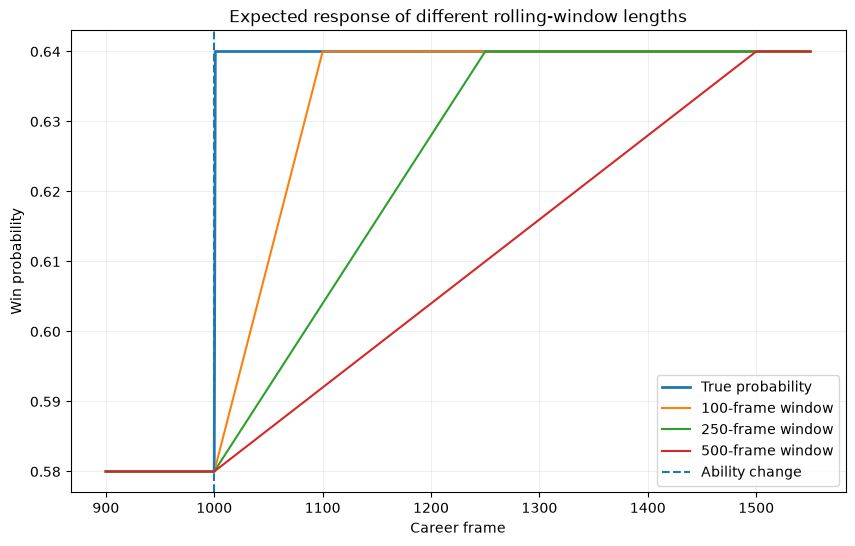

In [9]:
import matplotlib.pyplot as plt

# Focus on the period around the genuine change in ability.
plot_start = 900
plot_end = 1_550
frames = np.arange(1, total_frames + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    frames[plot_start - 1:plot_end],
    true_probability[plot_start - 1:plot_end],
    label="True probability",
    linewidth=2,
)

for window in window_sizes:
    plt.plot(
        frames[plot_start - 1:plot_end],
        expected_rolling[window].iloc[plot_start - 1:plot_end],
        label=f"{window}-frame window",
    )

plt.axvline(change_frame, linestyle="--", label="Ability change")

plt.xlabel("Career frame")
plt.ylabel("Win probability")
plt.title("Expected response of different rolling-window lengths")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### The expected response is controlled directly by window length

The chart makes the responsiveness difference easy to see.

All three estimators begin moving as soon as the player's true ability changes from 58% to 64%. But they move at different speeds because each new 64% frame replaces a different fraction of the retained history.

The 100-frame window reaches the new level after 100 post-change frames.

The 250-frame window reaches it after 250 frames.

The 500-frame window takes 500 frames.

Under this simple abrupt-change model, the relationship is therefore very direct: **the longer the window, the longer stale observations continue to influence the expected estimate.**

This clean expected-value picture deliberately removes sampling noise. The next step is to put that noise back in and compare how the three rolling estimates actually behave through the same simulated career.

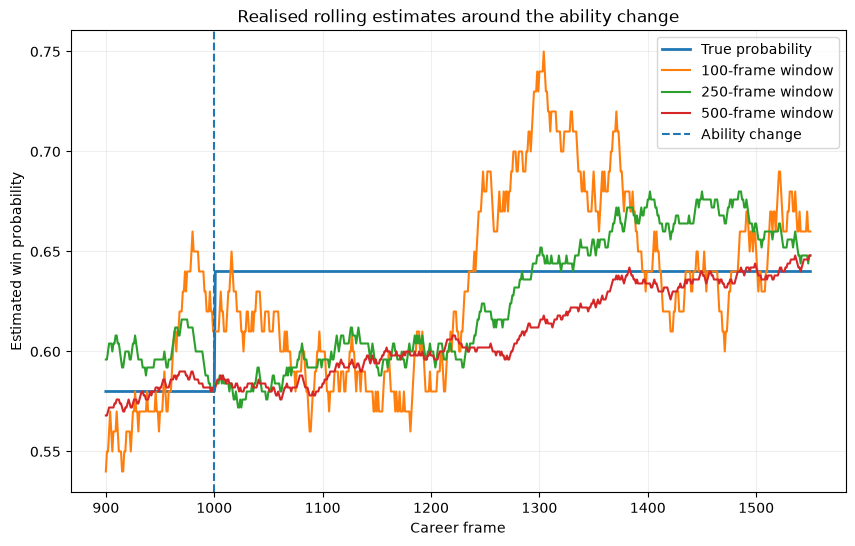

In [10]:
# Compare the realised rolling estimates around the same change point.
plt.figure(figsize=(10, 6))

plt.plot(
    frames[plot_start - 1:plot_end],
    true_probability[plot_start - 1:plot_end],
    label="True probability",
    linewidth=2,
)

for window in window_sizes:
    plt.plot(
        frames[plot_start - 1:plot_end],
        rolling_estimates[window].iloc[plot_start - 1:plot_end],
        label=f"{window}-frame window",
    )

plt.axvline(change_frame, linestyle="--", label="Ability change")

plt.xlabel("Career frame")
plt.ylabel("Estimated win probability")
plt.title("Realised rolling estimates around the ability change")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

### Responsiveness and stability appear together

The realised paths show the trade-off much more clearly than the expected-value calculation alone.

The 100-frame window reacts most quickly to the improvement in ability, but it is also visibly the most volatile. Even after all of its pre-change observations have disappeared, the estimate continues to move substantially above and below the true 64% level.

The 500-frame window behaves very differently. Its path is much smoother, but the improvement is absorbed only gradually because old 58% observations remain in the window for much longer.

The 250-frame window lies between the two.

This is an important distinction:

**a short window can recognise genuine change quickly without estimating the new level precisely.**

Likewise, a long window can produce a stable estimate while still being systematically behind a genuine change.

Window size therefore controls two things at the same time:

- how quickly old information is forgotten;
- how much sampling noise remains in the estimate.

Neither advantage comes for free.

In [11]:
# Put the two sides of the trade-off into one compact comparison.
tradeoff_summary = pd.DataFrame({
    "window_frames": window_sizes,
    "frames_to_fully_adapt": window_sizes,
    "theoretical_sd_pct_points": [
        theoretical_sd[window] * 100
        for window in window_sizes
    ],
})

tradeoff_summary.round(2)

,window_frames,frames_to_fully_adapt,theoretical_sd_pct_points
0,100,100,4.80
1,250,250,3.04
2,500,500,2.15


### Window size fixes our position on the trade-off

The comparison makes the cost of responsiveness explicit.

| Rolling window | Frames until old history is fully removed | Theoretical SD |
|---:|---:|---:|
| 100 frames | 100 frames | 4.80 percentage points |
| 250 frames | 250 frames | 3.04 percentage points |
| 500 frames | 500 frames | 2.15 percentage points |

The 100-frame window completely forgets the old ability level five times faster than the 500-frame window, but its sampling variability is more than twice as large.

The 500-frame window gives the most stable estimate, but it remains influenced by pre-change observations for the longest period.

The 250-frame window sits between them on both measures.

There is no contradiction here. Both effects come from the same choice: how many observations the estimator retains.

A smaller sample contains less stale information after a genuine change, but it also contains less information overall. A larger sample contains more information and is therefore more stable, but some of that information can become outdated.

So choosing a rolling-window length is not just choosing how much data to use. It is choosing **where to sit between responsiveness and stability**.

## Repeat the comparison across many careers

The single simulated career illustrates the trade-off, but any one path can be unusually lucky or unlucky.

To check that the pattern is systematic, we will simulate many independent careers and compare the three estimators at **frame 1,250**.

This is a useful checkpoint because the windows are in different states:

- the 100-frame window contains only post-change observations;
- the 250-frame window contains only post-change observations;
- the 500-frame window still contains 250 frames from the old 58% ability level and 250 frames from the new 64% level.

So at the same point in the career we should see both parts of the trade-off.

The shorter windows should be centred on the current 64% ability but differ in their sampling variability. The 500-frame window should be more stable, but its mean should still be pulled downward by stale history.

In [12]:
# Only the final 500 frames can affect the rolling estimates at frame 1,250.
# These contain 250 old-regime frames followed by 250 post-change frames.
n_careers = 10_000
rng = np.random.default_rng(456)

checkpoint_probabilities = np.concatenate([
    np.full(250, p_before),
    np.full(250, p_after),
])

checkpoint_results = (
    rng.random((n_careers, 500)) < checkpoint_probabilities
).astype(int)

# Calculate each rolling estimate from the relevant tail of the same careers.
checkpoint_estimates = {
    window: checkpoint_results[:, -window:].mean(axis=1)
    for window in window_sizes
}

pd.DataFrame({
    "window_frames": window_sizes,
    "mean_estimate_pct": [
        checkpoint_estimates[window].mean() * 100
        for window in window_sizes
    ],
    "sd_pct_points": [
        checkpoint_estimates[window].std(ddof=1) * 100
        for window in window_sizes
    ],
}).round(2)

,window_frames,mean_estimate_pct,sd_pct_points
0,100,64.00,4.80
1,250,64.03,3.04
2,500,61.02,2.21


### Repeated careers show the same trade-off

Across 10,000 simulated careers at frame 1,250:

- the 100-frame estimator averaged 64.00%, with an SD of 4.80 percentage points;
- the 250-frame estimator averaged 64.03%, with an SD of 3.04 percentage points;
- the 500-frame estimator averaged 61.02%, with an SD of 2.21 percentage points.

The 100- and 250-frame windows have already discarded every pre-change observation, so both are centred on the player's current 64% ability.

They differ in stability: the 100-frame estimate is substantially noisier because it uses fewer observations.

The 500-frame window is more stable, but at this checkpoint half of its retained observations still come from the old 58% ability level. Its expected estimate is therefore only 61%, which is exactly what the simulation produces.

This comparison makes the trade-off especially clear.

The longer window has the smallest spread, but its greater stability is partly stability around an **outdated value**.

The shorter windows are more representative of current ability, but their estimates vary more from career to career.

More stability is therefore not automatically better if the data being stabilised include observations that are no longer representative.

## Sanity check: what if ability never changed?

The 500-frame estimator was centred below 64% at frame 1,250 because part of its window still contained observations from the old 58% ability level.

That should not happen if the player's true ability has been 64% throughout.

To check this, we can repeat the comparison under a constant 64% process.

If all three rolling windows are then centred near 64%, it confirms that the earlier difference was caused by stale history rather than by any inherent bias in the longer window.

We should still expect the same stability ordering:

- 100 frames: most variable;
- 250 frames: intermediate;
- 500 frames: least variable.

When the history remains representative, retaining more of it should simply make the estimate more stable.

In [13]:
# Simulate 10,000 careers where the relevant history is always generated at 64%.
rng = np.random.default_rng(789)

constant_results = (
    rng.random((n_careers, 500)) < p_after
).astype(int)

constant_estimates = {
    window: constant_results[:, -window:].mean(axis=1)
    for window in window_sizes
}

pd.DataFrame({
    "window_frames": window_sizes,
    "mean_estimate_pct": [
        constant_estimates[window].mean() * 100
        for window in window_sizes
    ],
    "sd_pct_points": [
        constant_estimates[window].std(ddof=1) * 100
        for window in window_sizes
    ],
}).round(2)

,window_frames,mean_estimate_pct,sd_pct_points
0,100,64.03,4.83
1,250,64.01,3.08
2,500,64.02,2.15


### The longer window is not inherently biased

With ability fixed at 64% throughout, all three rolling estimators are centred correctly:

- 100-frame window: mean 64.03%;
- 250-frame window: mean 64.01%;
- 500-frame window: mean 64.02%.

Their variability still differs substantially:

- 100 frames: SD 4.83 percentage points;
- 250 frames: SD 3.08 percentage points;
- 500 frames: SD 2.15 percentage points.

This confirms that the 500-frame estimator was not below 64% in the earlier comparison because longer windows are inherently biased.

It was below 64% because its retained history was no longer fully representative of the player's current ability.

When the underlying process is stable, remembering more history is useful: the estimate remains centred correctly and becomes more precise.

The problem appears when the process changes. Then the same old observations that previously improved precision can temporarily make the estimate stale.

## Conclusion

Study 07 showed that retaining an entire history can make an estimate stale when a player's underlying ability changes.

Study 08 showed that a rolling window can reduce that staleness, but only by using fewer observations and accepting greater sampling uncertainty.

Study 09 makes the next part explicit: **the amount of history retained determines where the estimator sits on that trade-off.**

Under the same genuine change from 58% to 64%:

- a 100-frame window completely removes the old regime after 100 frames, but has a theoretical SD of about 4.80 percentage points;
- a 250-frame window takes 250 frames to remove it, with an SD of about 3.04 percentage points;
- a 500-frame window takes 500 frames, with an SD of about 2.15 percentage points.

Repeated simulation produced the same pattern.

At frame 1,250, the 100- and 250-frame estimators were already centred on the current 64% ability, while the 500-frame estimator remained centred near 61% because half of its retained history still came from the old 58% regime.

When ability was instead fixed at 64% throughout, all three estimators were centred correctly and the longer windows were simply more stable.

So neither short nor long windows are inherently better.

Short windows respond quickly because they forget old observations quickly, but they are noisier because they use less data.

Long windows are more stable because they use more data, but they can remain stale for longer when the underlying process changes.

The central result is therefore:

> **How much history we remember determines the balance between responsiveness and stability.**

This study deliberately does not choose an optimal window length. Doing that would require deciding how much we value responsiveness relative to stability, and would move from describing the trade-off to solving a different problem.